# Hydrodynamic plots — Merganser

Generates four figures from the OrcaWave/OrcaFlex export, for the **Heave, Pitch
and Roll** degrees of freedom (in that order):

1. **Added mass** vs period
2. **Radiation damping** vs period
3. **Load RAO** (amplitude) vs period — one line per wave heading
4. **Displacement RAO** (amplitude) vs period — one line per wave heading


## Imports and settings

In [46]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
%matplotlib inline

# Larger, clearer text everywhere
plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 20,
    "axes.labelsize": 17,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "legend.title_fontsize": 15,
    "figure.titlesize": 24,
})

XLSX = "Harlequin_DAresults_spring.xlsx"   # adjust path if needed
configuration = "Harlequin spring"  # for plot titles and filenames

# Degrees of freedom to plot, in the requested order.
# Values are the 0-based DOF index in the file (Surge=0 ... Yaw=5).
DOFS = [("Heave", 2), ("Pitch", 4), ("Roll", 3)]

## Reading the data

**Added mass / Damping** are stored as blocks: one 6x6 DOF matrix per period.
Each block starts with a marker (`... for period X,Ys`) in column 1; the matrix
begins 5 rows below it. We take the diagonal terms (the direct added mass /
damping for each own degree of freedom).

**RAO sheets**: column 0 = wave heading, column 1 = period, then an
(Ampl., Phase) pair per DOF. We plot the amplitude.

In [47]:
def read_matrix_sheet(sheet):
    """Read 'Added mass'/'Damping'. Returns (periods, diag[n, 6])."""
    df = pd.read_excel(XLSX, sheet_name=sheet, header=None)

    periods, diag = [], []
    for i in range(df.shape[0]):
        marker = df.iat[i, 1] if df.shape[1] > 1 else None
        if isinstance(marker, str) and "period" in marker.lower():
            txt = marker.lower().split("period")[-1].replace("s", "").strip()
            period = float(txt.replace(",", "."))          # NL comma -> dot
            block = df.iloc[i + 5 : i + 11, 1:7].to_numpy(dtype=float)
            periods.append(period)
            diag.append(np.diag(block))

    order = np.argsort(periods)
    return np.array(periods)[order], np.array(diag)[order]


def read_rao_sheet(sheet):
    """Read an RAO sheet. Returns (headings, units, {heading: (periods, amp[n, 6])})."""
    df = pd.read_excel(XLSX, sheet_name=sheet, header=None)

    units = [df.iat[8, 2 + 2 * d] for d in range(6)]
    body = df.iloc[9:].copy()
    body = body[body[0].notna()]

    headings = sorted(body[0].unique())
    amp_cols = [2 + 2 * d for d in range(6)]

    data = {}
    for h in headings:
        sub = body[body[0] == h].sort_values(1)
        data[h] = (sub[1].to_numpy(dtype=float), sub[amp_cols].to_numpy(dtype=float))

    return headings, units, data

In [48]:
def plot_matrix(periods, diag, title, ylabel1, ylabel2):
    fig, axes = plt.subplots(1, len(DOFS), figsize=(18, 6))
    for ax, (name, idx) in zip(axes, DOFS):
        ax.plot(periods, diag[:, idx], lw=2.2, color="tab:blue")
        ax.set_title(f"{name} ")
        ax.set_xlabel("Period [s]")
        if ax == axes[0]:  # only label the first subplot
            ax.set_ylabel(ylabel1)
        else:
            ax.set_ylabel(ylabel2)
        ax.grid(True, alpha=0.3)
        ax.tick_params(width=1.2, length=6)
    fig.suptitle(title, fontweight="bold")
    fig.tight_layout(rect=[0, 0, 1, 0.94])
    return fig


def plot_rao(headings, units, data, title):
    fig, axes = plt.subplots(1, len(DOFS), figsize=(18, 6))
    for ax, (name, idx) in zip(axes, DOFS):
        for h in headings:
            periods, amp = data[h]
            ax.plot(periods, amp[:, idx], lw=2.0, label=f"{h:g}°")
        ax.set_title(name, fontweight="bold")
        ax.set_xlabel("Period [s]")
        if ax == axes[0]:  # only label the first subplot
            ax.set_ylabel(f"Amplitude [{units[idx]}]")
        else:  # only add legend to the middle subplot
            ax.set_ylabel(f"Amplitude [{units[idx]}]")

        ax.grid(True, alpha=0.3)
        ax.tick_params(width=1.2, length=6)
        ax.legend(title="Wave heading")
    fig.suptitle(title, fontweight="bold")
    fig.tight_layout(rect=[0, 0, 1, 0.94])
    return fig

## 1. Added mass vs period

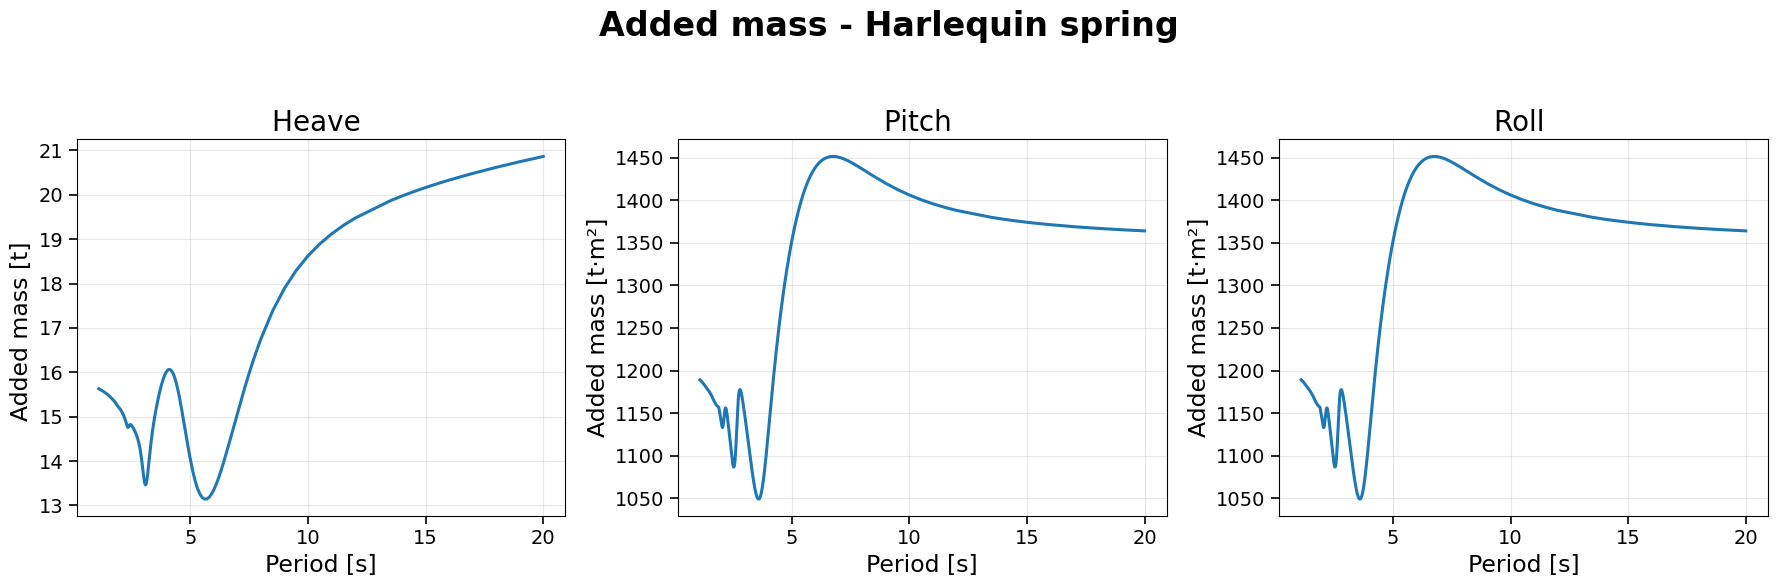

In [49]:
p, diag = read_matrix_sheet("Added mass")
fig = plot_matrix(p, diag, f"Added mass - {configuration}", "Added mass [t] ", "Added mass [t·m²]")
fig.savefig("1s_added_mass.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. Radiation damping vs period

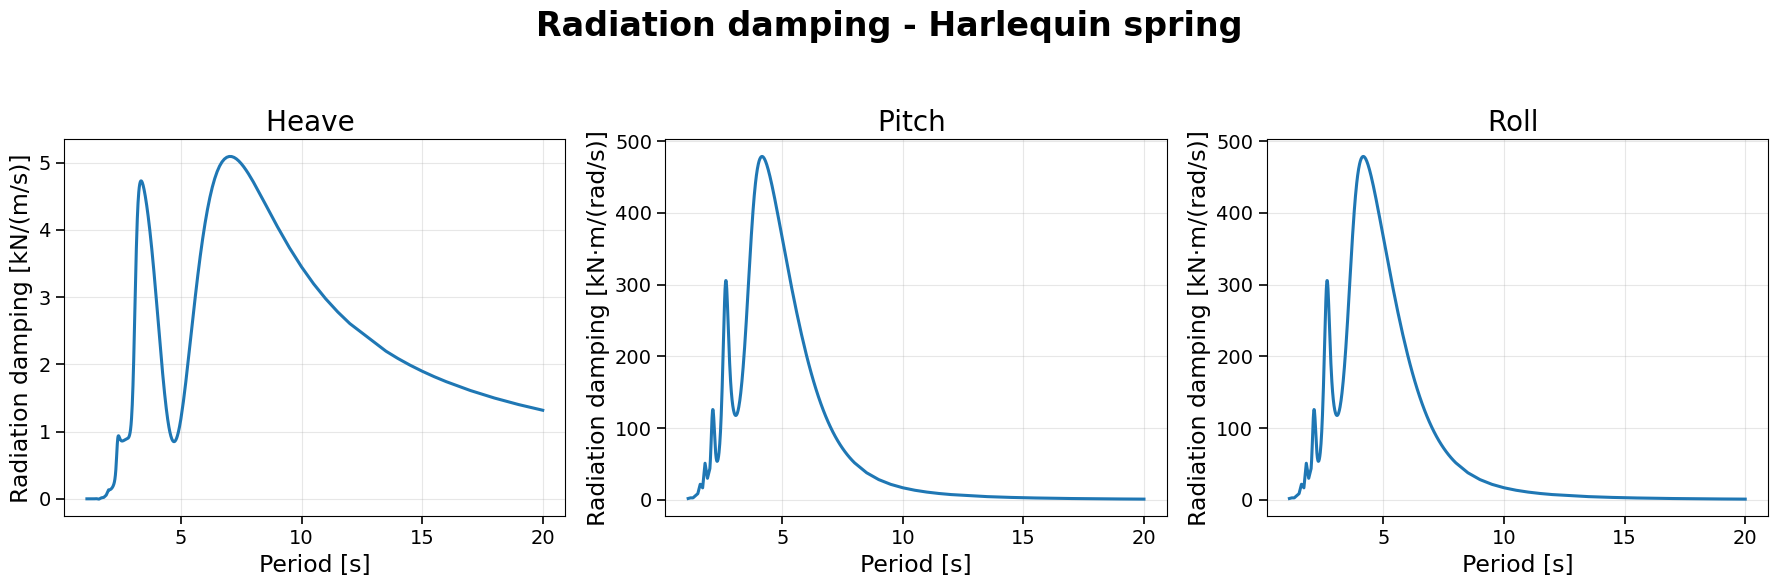

In [50]:
p, diag = read_matrix_sheet("Damping")
fig = plot_matrix(p, diag, f"Radiation damping - {configuration}", "Radiation damping [kN/(m/s)]", "Radiation damping [kN·m/(rad/s)]")
fig.savefig("2s_damping.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Load RAO vs period — one line per wave heading

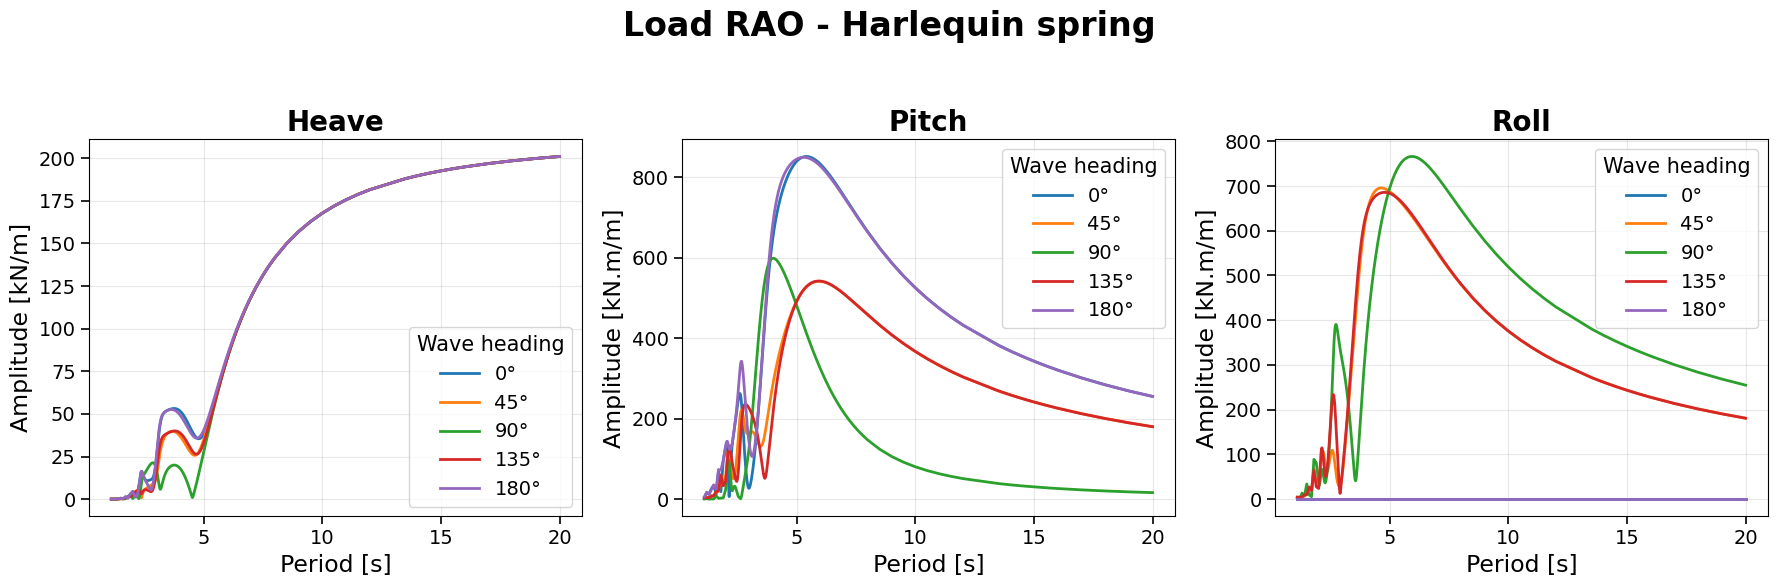

In [51]:
headings, units, data = read_rao_sheet("Load RAOs (Haskind)")
fig = plot_rao(headings, units, data, f"Load RAO - {configuration}")
fig.savefig("3S_load_rao.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Displacement RAO vs period — one line per wave heading

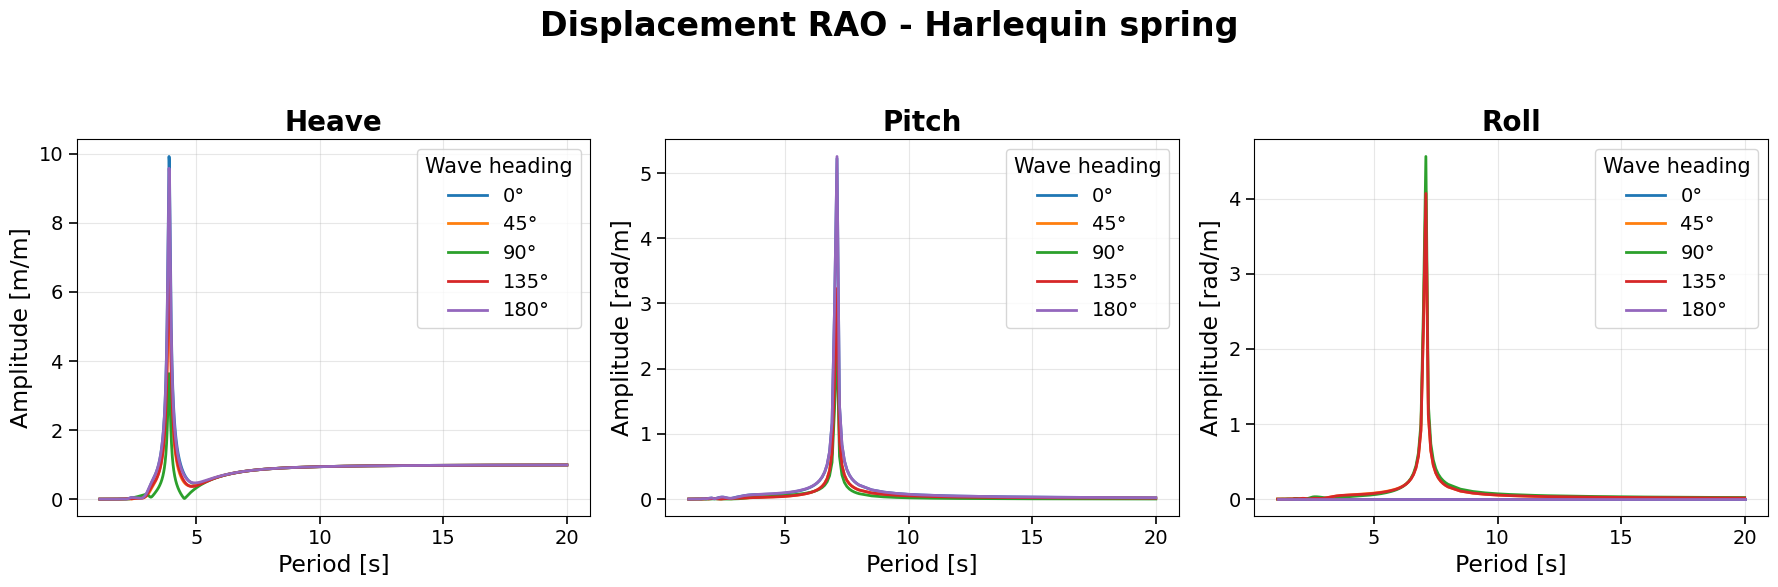

In [52]:
headings, units, data = read_rao_sheet("Displacement RAOs")
fig = plot_rao(headings, units, data, f"Displacement RAO - {configuration}")
fig.savefig("4s_displacement_rao.png", dpi=150, bbox_inches="tight")
plt.show()